In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import glob
import json
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

#==================================================================================================

PLOT_TITLE    = 'Benchmark for Geant4-DNA on AMD EPYC (Milan)'
PDF_FILE_NAME = 'plot-AMD-alma.pdf'

SIM_DATA = [
    {'dir': 'native', 'label': 'G4DNA-10.7.2 RHEL8.4 (native, gcc8)'},
]

#==================================================================================================

WORKDIR = os.getcwd()

def make_data_frame(path):
    os.chdir(path)
  
    flist = glob.glob('benchmark_*.json')
    flist.sort(key=lambda s: int(re.search(r'\d+', s).group()))
  
    thread_num = []
    eps = []
    for x in flist:
        thread_num.append(int(re.search(r'\d+', x).group()))
        f = open(x, 'r')
        js = json.load(f)
        eps.append(js['summary']['throughput'])

    df = pd.DataFrame(data=dict(ThreadNum=thread_num, EPS=eps))
  
    os.chdir(WORKDIR)
  
    return df

#--------------------------------------------------------------------------------------------------
def gvalue(path, name):
    os.chdir(path)
    
    flist = glob.glob('benchmark_*.json')
    flist.sort(key=lambda s: int(re.search(r'\d+', s).group()))
    
    thread_num = []
    gval_start = []
    gval_end = []
    
    for x in flist:
        thread_num.append(int(re.search(r'\d+', x).group()))
        f = open(x, 'r')
        js = json.load(f)
        gval_start.append(js['summary']['gvalue'][name]['chem_start'])
        gval_end.append(js['summary']['gvalue'][name]['chem_end'])
        
    df = pd.DataFrame(data=dict(ThreadNum=thread_num, GValStart=gval_start, GValEnd=gval_end))
    
    os.chdir(WORKDIR)
    
    return df

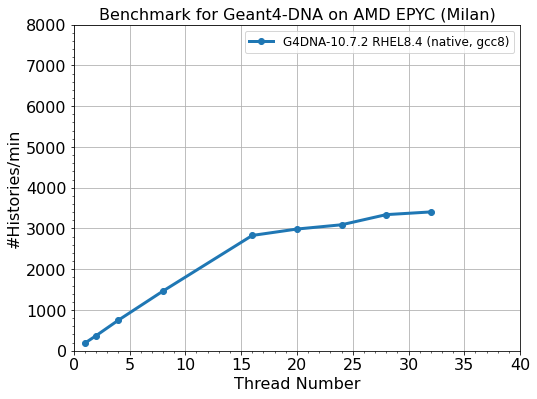

In [2]:
fig = plt.figure(figsize=(8,6))
plt.title(PLOT_TITLE, fontsize=16)

for x in SIM_DATA:
    df = make_data_frame(x['dir'])
    plt.plot(df['ThreadNum'], df['EPS'], marker='o', linewidth=3.0, label=x['label'])

plt.xlabel("Thread Number", fontsize=16)
plt.ylabel("#Histories/min", fontsize=16)
plt.xlim(0, 40)
plt.ylim(0, 8000)
plt.tick_params(labelsize=16)
plt.minorticks_on()
plt.legend(fontsize=12)
plt.grid()
plt.plot()

# save as a PDF file
pp = PdfPages(PDF_FILE_NAME)
pp.savefig(fig)
pp.close()

[]

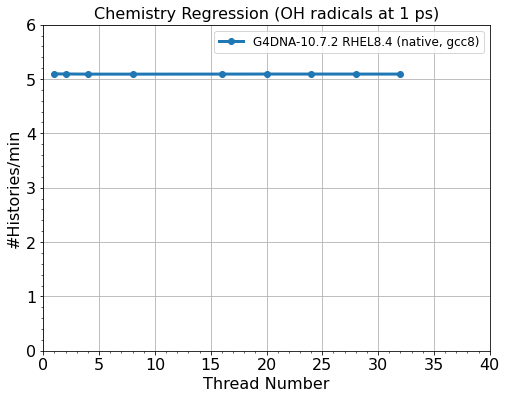

In [3]:
fig = plt.figure(figsize=(8,6))
plt.title("Chemistry Regression (OH radicals at 1 ps)", fontsize=16)

for x in SIM_DATA:
    df = gvalue(x['dir'], 'hydroxyl_radical')
    plt.plot(df['ThreadNum'], df['GValStart'], marker='o', linewidth=3.0, label=x['label'])
    
plt.xlabel("Thread Number", fontsize=16)
plt.ylabel("#Histories/min", fontsize=16)
plt.xlim(0, 40)
plt.ylim(0, 6)
plt.tick_params(labelsize=16)
plt.minorticks_on()
plt.legend(fontsize=12)
plt.grid()
plt.plot()

[]

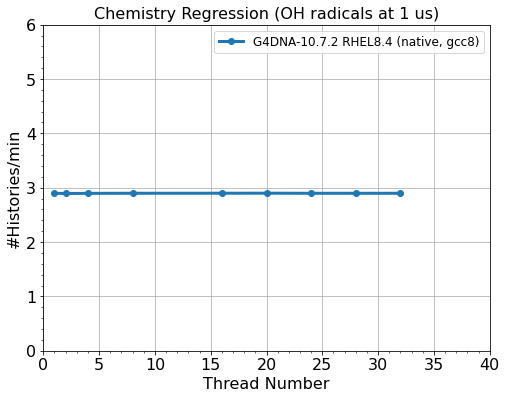

In [4]:
fig = plt.figure(figsize=(8,6))
plt.title("Chemistry Regression (OH radicals at 1 us)", fontsize=16)

for x in SIM_DATA:
    df = gvalue(x['dir'], 'hydroxyl_radical')
    plt.plot(df['ThreadNum'], df['GValEnd'], marker='o', linewidth=3.0, label=x['label'])
    
plt.xlabel("Thread Number", fontsize=16)
plt.ylabel("#Histories/min", fontsize=16)
plt.xlim(0, 40)
plt.ylim(0, 6)
plt.tick_params(labelsize=16)
plt.minorticks_on()
plt.legend(fontsize=12)
plt.grid()
plt.plot()

[]

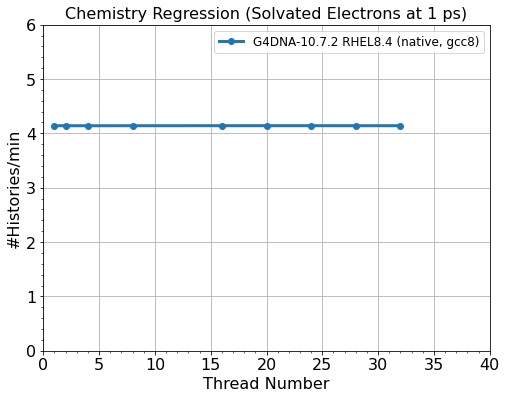

In [5]:
fig = plt.figure(figsize=(8,6))
plt.title("Chemistry Regression (Solvated Electrons at 1 ps)", fontsize=16)

for x in SIM_DATA:
    df = gvalue(x['dir'], 'solvated_electron')
    plt.plot(df['ThreadNum'], df['GValStart'], marker='o', linewidth=3.0, label=x['label'])
    
plt.xlabel("Thread Number", fontsize=16)
plt.ylabel("#Histories/min", fontsize=16)
plt.xlim(0, 40)
plt.ylim(0, 6)
plt.tick_params(labelsize=16)
plt.minorticks_on()
plt.legend(fontsize=12)
plt.grid()
plt.plot()

[]

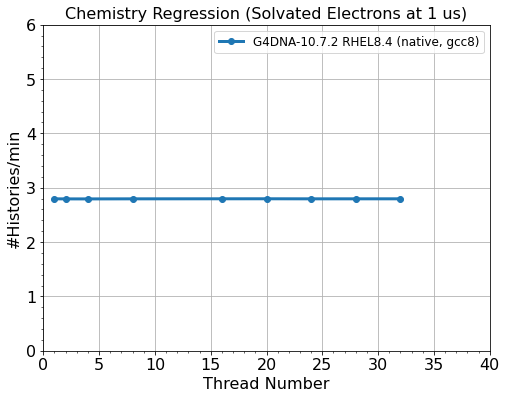

In [6]:
fig = plt.figure(figsize=(8,6))
plt.title("Chemistry Regression (Solvated Electrons at 1 us)", fontsize=16)

for x in SIM_DATA:
    df = gvalue(x['dir'], 'solvated_electron')
    plt.plot(df['ThreadNum'], df['GValEnd'], marker='o', linewidth=3.0, label=x['label'])
    
plt.xlabel("Thread Number", fontsize=16)
plt.ylabel("#Histories/min", fontsize=16)
plt.xlim(0, 40)
plt.ylim(0, 6)
plt.tick_params(labelsize=16)
plt.minorticks_on()
plt.legend(fontsize=12)
plt.grid()
plt.plot()

[]

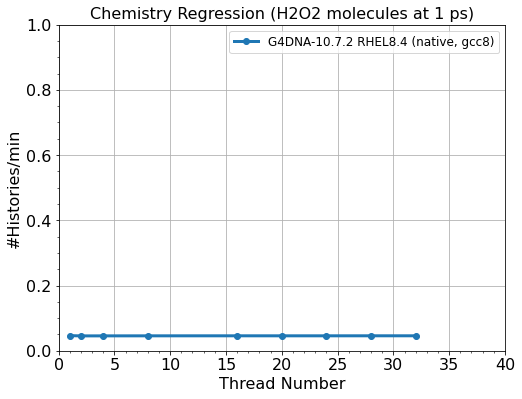

In [7]:
fig = plt.figure(figsize=(8,6))
plt.title("Chemistry Regression (H2O2 molecules at 1 ps)", fontsize=16)

for x in SIM_DATA:
    df = gvalue(x['dir'], 'H2O2')
    plt.plot(df['ThreadNum'], df['GValStart'], marker='o', linewidth=3.0, label=x['label'])
    
plt.xlabel("Thread Number", fontsize=16)
plt.ylabel("#Histories/min", fontsize=16)
plt.xlim(0, 40)
plt.ylim(0, 1)
plt.tick_params(labelsize=16)
plt.minorticks_on()
plt.legend(fontsize=12)
plt.grid()
plt.plot()

[]

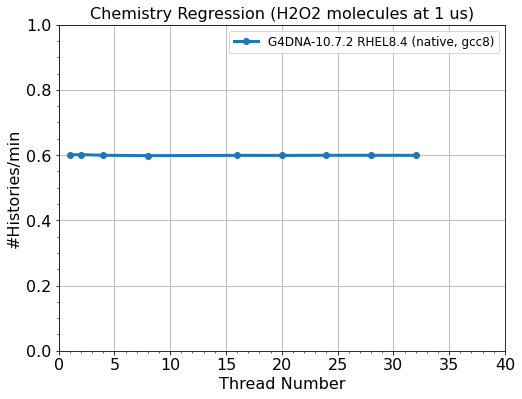

In [8]:
fig = plt.figure(figsize=(8,6))
plt.title("Chemistry Regression (H2O2 molecules at 1 us)", fontsize=16)

for x in SIM_DATA:
    df = gvalue(x['dir'], 'H2O2')
    plt.plot(df['ThreadNum'], df['GValEnd'], marker='o', linewidth=3.0, label=x['label'])
    
plt.xlabel("Thread Number", fontsize=16)
plt.ylabel("#Histories/min", fontsize=16)
plt.xlim(0, 40)
plt.ylim(0, 1)
plt.tick_params(labelsize=16)
plt.minorticks_on()
plt.legend(fontsize=12)
plt.grid()
plt.plot()